# Case Study 1 -- BrewBuzz: End-to-End Order Analysis
One continuous pipeline, raw file to executive summary: load, audit, clean, engineer
features, detect outliers with NumPy, merge, group/pivot/crosstab, analyze the time
series, segment customers, visualize, and export -- every pandas/NumPy tool from
Weeks 3-5 used together on one real dataset, start to finish.

## The Brief
Store Ops and Finance sent over the raw export and three questions:
1. What's actual, trustworthy revenue -- after the known data-quality problems are dealt with, not before?
2. Which stores, regions, and products are winning, and how does revenue move month to month?
3. Which customers matter most, and how many customer records have an email too broken to use for the next marketing campaign?

Nobody is going to tell you which cell answers which question -- that's the actual job.

## 1. Load and First Look

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/brewbuzz_raw_orders.csv")
print(df.shape)   # (100150, 13)
df.head()

(100150, 13)


,order_id,order_date,store_name,customer_id,customer_email,product_name,category,quantity,unit_price,promo_code,discount_percent,payment_method,order_total
0,197090,2025-06-07 04:26:04,BrewBuzz Uptown,8440,customer8440@example.com,Green Tea,Tea,1,-3.22,NaN,0.0,Cash,3.25
1,140550,2024-10-07 10:47:29,BrewBuzz Airport,8136,customer8136@example.com,Blueberry Muffin,Pastry,2,3.5,BOGO,50.0,App,3.50
2,136717,2025-06-11 23:33:43,BrewBuzz Riverside,14068,customer14068@example.com,Latte,Coffee,1,4.5,BOGO,0.0,Cash,4.50
3,100461,2025-10-17 11:50:16,BrewBuzz Riverside,9791,customer9791@example.com,Americano,Coffee,3,3.5,BOGO,50.0,Card,5.25
4,104866,2025-08-04 12:06:14,BrewBuzz Riverside,2656,customer2656@example.com,Croissant,Pastry,3,3.75,NaN,0.0,App,11.25


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100150 entries, 0 to 100149
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   order_id          100150 non-null  int64  
 1   order_date        99990 non-null   str    
 2   store_name        100150 non-null  str    
 3   customer_id       100150 non-null  int64  
 4   customer_email    92188 non-null   str    
 5   product_name      100150 non-null  str    
 6   category          100150 non-null  str    
 7   quantity          99932 non-null   str    
 8   unit_price        99867 non-null   str    
 9   promo_code        28724 non-null   str    
 10  discount_percent  100150 non-null  float64
 11  payment_method    100150 non-null  str    
 12  order_total       99717 non-null   float64
dtypes: float64(2), int64(2), str(9)
memory usage: 9.9 MB


In [5]:
print(df.isnull().sum())

order_id                0
order_date            160
store_name              0
customer_id             0
customer_email       7962
product_name            0
category                0
quantity              218
unit_price            283
promo_code          71426
discount_percent        0
payment_method          0
order_total           433
dtype: int64


## 2. Data Quality Audit
Before fixing anything: how big is the problem, column by column?

In [7]:
audit.head()

,missing_count,missing_percent
order_id,0,0.00
order_date,160,0.16
store_name,0,0.00
customer_id,0,0.00
customer_email,7962,7.95


In [3]:
audit = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": (df.isnull().mean() * 100).round(2),
})
print(audit[audit.missing_count > 0])
print("exact duplicate rows:", df.duplicated().sum())   # 150

                missing_count  missing_percent
order_date                160             0.16
customer_email           7962             7.95
quantity                  218             0.22
unit_price                283             0.28
promo_code              71426            71.32
order_total               433             0.43
exact duplicate rows: 150


`promo_code` missing on ~71% of rows isn't dirty -- it's genuinely empty for every
order with no promo. `order_date`, `quantity`, `unit_price`, and `order_total` missing
on well under 1% each are the real problems, alongside the 150 duplicate rows -- this
is the same audit from Week 4 Session 2, now the first link in a longer chain.

## 3. Cleaning
Same techniques as the Week 4 lesson -- `pd.to_numeric(errors="coerce")`, a
canonical-name lookup instead of `.str.title()` (title-casing `"BrewBuzz"` with no
internal space silently mangles it to `"Brewbuzz"`, which then fails every merge with
no error, just a column full of `NaN`) -- run once, back to back, as a real pipeline
would. One addition the lesson didn't require: this case study also needs a *valid*
`order_date` for the time-series work later, so a bad date now disqualifies a row too.

In [4]:
print("Before exact duplicate rows:", df.duplicated().sum())   
df = df.drop_duplicates()
print("After cleaning exact duplicate rows:", df.duplicated().sum())  

Before exact duplicate rows: 150
After cleaning exact duplicate rows: 0


In [5]:
rows_in = len(df)
df = df.drop_duplicates()

df["quantity_clean"] = pd.to_numeric(df["quantity"], errors="coerce")
df["unit_price_clean"] = pd.to_numeric(df["unit_price"], errors="coerce")
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

stores = pd.read_csv("../data/brewbuzz_stores.csv")
canonical = {name.strip().lower(): name for name in stores["store_name"]}
df["store_name_clean"] = df["store_name"].str.strip().str.lower().map(canonical)
print("unmapped store names:", df["store_name_clean"].isna().sum())

unmapped store names: 0


In [6]:
print(canonical)

{'brewbuzz downtown': 'BrewBuzz Downtown', 'brewbuzz uptown': 'BrewBuzz Uptown', 'brewbuzz airport': 'BrewBuzz Airport', 'brewbuzz mall': 'BrewBuzz Mall', 'brewbuzz riverside': 'BrewBuzz Riverside'}


In [10]:
df.head()

,order_id,order_date,store_name,customer_id,customer_email,product_name,category,quantity,unit_price,promo_code,discount_percent,payment_method,order_total,quantity_clean,unit_price_clean,store_name_clean
0,197090,2025-06-07 04:26:04,BrewBuzz Uptown,8440,customer8440@example.com,Green Tea,Tea,1,-3.22,NaN,0.0,Cash,3.25,1.0,-3.22,BrewBuzz Uptown
1,140550,2024-10-07 10:47:29,BrewBuzz Airport,8136,customer8136@example.com,Blueberry Muffin,Pastry,2,3.5,BOGO,50.0,App,3.50,2.0,3.50,BrewBuzz Airport
2,136717,2025-06-11 23:33:43,BrewBuzz Riverside,14068,customer14068@example.com,Latte,Coffee,1,4.5,BOGO,0.0,Cash,4.50,1.0,4.50,BrewBuzz Riverside
3,100461,2025-10-17 11:50:16,BrewBuzz Riverside,9791,customer9791@example.com,Americano,Coffee,3,3.5,BOGO,50.0,Card,5.25,3.0,3.50,BrewBuzz Riverside
4,104866,2025-08-04 12:06:14,BrewBuzz Riverside,2656,customer2656@example.com,Croissant,Pastry,3,3.75,NaN,0.0,App,11.25,3.0,3.75,BrewBuzz Riverside


In [6]:
before_filter = len(df)
valid_rows = (
    (df["quantity_clean"] > 0)
    & (df["unit_price_clean"] > 0)
    & df["order_date"].notna()
)
df_clean = df[valid_rows].copy()

df_clean["order_total_calc"] = (
    df_clean["quantity_clean"] * df_clean["unit_price_clean"]
    * (1 - df_clean["discount_percent"].fillna(0) / 100)
).round(2)

print("rows kept:", len(df_clean))   # 98230


rows kept: 98230


In [13]:
df_clean.head()

,order_id,order_date,store_name,customer_id,customer_email,product_name,category,quantity,unit_price,promo_code,discount_percent,payment_method,order_total,quantity_clean,unit_price_clean,store_name_clean,order_total_calc
1,140550,2024-10-07 10:47:29,BrewBuzz Airport,8136,customer8136@example.com,Blueberry Muffin,Pastry,2,3.5,BOGO,50.0,App,3.50,2.0,3.50,BrewBuzz Airport,3.50
2,136717,2025-06-11 23:33:43,BrewBuzz Riverside,14068,customer14068@example.com,Latte,Coffee,1,4.5,BOGO,0.0,Cash,4.50,1.0,4.50,BrewBuzz Riverside,4.50
3,100461,2025-10-17 11:50:16,BrewBuzz Riverside,9791,customer9791@example.com,Americano,Coffee,3,3.5,BOGO,50.0,Card,5.25,3.0,3.50,BrewBuzz Riverside,5.25
4,104866,2025-08-04 12:06:14,BrewBuzz Riverside,2656,customer2656@example.com,Croissant,Pastry,3,3.75,NaN,0.0,App,11.25,3.0,3.75,BrewBuzz Riverside,11.25
5,159468,2025-03-23 20:13:34,BrewBuzz Uptown,2047,customer2047@example.com,Croissant,Pastry,4,3.75,BOGO,50.0,Card,7.50,4.0,3.75,BrewBuzz Uptown,7.50


## 4. The Data Quality Audit Trail
A real pipeline doesn't just clean data quietly -- it keeps a ledger of what was
removed and why, so anyone downstream can see exactly how "raw" became "clean" instead
of trusting a black box.

In [7]:
audit_trail = pd.DataFrame([
    {"step": "raw file loaded", "rows": rows_in},
    {"step": "exact duplicates dropped", "rows": before_filter,
     "removed": rows_in - before_filter},
    {"step": "bad quantity / price / date dropped", "rows": len(df_clean),
     "removed": before_filter - len(df_clean)},
])
audit_trail

,step,rows,removed
0,raw file loaded,100000,NaN
1,exact duplicates dropped,100000,0.0
2,bad quantity / price / date dropped,98230,1770.0


## 5. Feature Engineering
Pull date parts out of `order_date`, and bucket `quantity_clean` with `np.select` --
the cleaner way to write "if/elif/elif/else" across several thresholds at once,
compared to nesting `np.where` calls inside each other.

In [26]:
print(conditions[0])

[1         False
2          True
3         False
4         False
5         False
          ...  
100145    False
100146     True
100147    False
100148    False
100149    False
Name: quantity_clean, Length: 98230, dtype: bool, 1          True
2         False
3         False
4         False
5         False
          ...  
100145    False
100146    False
100147    False
100148    False
100149    False
Name: quantity_clean, Length: 98230, dtype: bool, 1         False
2         False
3          True
4          True
5         False
          ...  
100145    False
100146    False
100147    False
100148    False
100149    False
Name: quantity_clean, Length: 98230, dtype: bool, 1         False
2         False
3         False
4         False
5          True
          ...  
100145     True
100146    False
100147     True
100148     True
100149     True
Name: quantity_clean, Length: 98230, dtype: bool]


In [8]:
df_clean["order_month"] = df_clean["order_date"].dt.to_period("M").astype(str)
df_clean["order_dow"] = df_clean["order_date"].dt.day_name()
df_clean["is_weekend"] = df_clean["order_dow"].isin(["Saturday", "Sunday"])

conditions = [
    df_clean["quantity_clean"] == 1,
    df_clean["quantity_clean"] == 2,
    df_clean["quantity_clean"] == 3,
    df_clean["quantity_clean"] >= 4,
]
choices = ["Single", "Pair", "Triple", "Quad"]
df_clean["order_size"] = np.select(conditions, choices, default="Unknown")
df_clean["order_size"].value_counts()

order_size
Single    24636
Triple    24583
Quad      24551
Pair      24460
Name: count, dtype: int64

In [16]:
df_clean.head()

,order_id,order_date,store_name,customer_id,customer_email,product_name,category,quantity,unit_price,promo_code,...,payment_method,order_total,quantity_clean,unit_price_clean,store_name_clean,order_total_calc,order_month,order_dow,is_weekend,order_size
1,140550,2024-10-07 10:47:29,BrewBuzz Airport,8136,customer8136@example.com,Blueberry Muffin,Pastry,2,3.5,BOGO,...,App,3.50,2.0,3.50,BrewBuzz Airport,3.50,2024-10,Monday,False,Pair
2,136717,2025-06-11 23:33:43,BrewBuzz Riverside,14068,customer14068@example.com,Latte,Coffee,1,4.5,BOGO,...,Cash,4.50,1.0,4.50,BrewBuzz Riverside,4.50,2025-06,Wednesday,False,Single
3,100461,2025-10-17 11:50:16,BrewBuzz Riverside,9791,customer9791@example.com,Americano,Coffee,3,3.5,BOGO,...,Card,5.25,3.0,3.50,BrewBuzz Riverside,5.25,2025-10,Friday,False,Triple
4,104866,2025-08-04 12:06:14,BrewBuzz Riverside,2656,customer2656@example.com,Croissant,Pastry,3,3.75,NaN,...,App,11.25,3.0,3.75,BrewBuzz Riverside,11.25,2025-08,Monday,False,Triple
5,159468,2025-03-23 20:13:34,BrewBuzz Uptown,2047,customer2047@example.com,Croissant,Pastry,4,3.75,BOGO,...,Card,7.50,4.0,3.75,BrewBuzz Uptown,7.50,2025-03,Sunday,True,Quad


## 6. Flagging Bad Emails Instead of Dropping Them
Unlike `quantity`/`price`/`date`, a broken `customer_email` doesn't make the *order*
untrustworthy -- the sale still happened. This is a marketing data-quality question,
not a revenue one, so the row stays and gets flagged instead of dropped.

In [9]:
import re

email_pattern = re.compile(r"^[^@\s]+@[^@\s]+\.[^@.\s]+$")

def is_valid_email(value):
    if pd.isna(value) or value == "":
        return False
    return bool(email_pattern.match(value)) and ".." not in value

df_clean["email_valid"] = df_clean["customer_email"].apply(is_valid_email)
print(df_clean["email_valid"].value_counts())
print(f"{(~df_clean['email_valid']).sum():,} rows have an email too broken to market to")

email_valid
True     90050
False     8180
Name: count, dtype: int64
8,180 rows have an email too broken to market to


In [29]:
df_clean.head()

,order_id,order_date,store_name,customer_id,customer_email,product_name,category,quantity,unit_price,promo_code,...,order_total,quantity_clean,unit_price_clean,store_name_clean,order_total_calc,order_month,order_dow,is_weekend,order_size,email_valid
1,140550,2024-10-07 10:47:29,BrewBuzz Airport,8136,customer8136@example.com,Blueberry Muffin,Pastry,2,3.5,BOGO,...,3.50,2.0,3.50,BrewBuzz Airport,3.50,2024-10,Monday,False,Pair,True
2,136717,2025-06-11 23:33:43,BrewBuzz Riverside,14068,customer14068@example.com,Latte,Coffee,1,4.5,BOGO,...,4.50,1.0,4.50,BrewBuzz Riverside,4.50,2025-06,Wednesday,False,Single,True
3,100461,2025-10-17 11:50:16,BrewBuzz Riverside,9791,customer9791@example.com,Americano,Coffee,3,3.5,BOGO,...,5.25,3.0,3.50,BrewBuzz Riverside,5.25,2025-10,Friday,False,Triple,True
4,104866,2025-08-04 12:06:14,BrewBuzz Riverside,2656,customer2656@example.com,Croissant,Pastry,3,3.75,NaN,...,11.25,3.0,3.75,BrewBuzz Riverside,11.25,2025-08,Monday,False,Triple,True
5,159468,2025-03-23 20:13:34,BrewBuzz Uptown,2047,customer2047@example.com,Croissant,Pastry,4,3.75,BOGO,...,7.50,4.0,3.75,BrewBuzz Uptown,7.50,2025-03,Sunday,True,Quad,True


## 7. NumPy Outlier Detection -- the IQR Method
Week 4 flagged outliers with mean +/- 3 standard deviations. Here's a second, more
robust approach for data that isn't a clean bell curve: the interquartile range (IQR).
Anything more than 1.5x the IQR beyond the 25th/75th percentile line is flagged --
entirely NumPy, no pandas-specific function involved.

In [10]:
totals = df_clean["order_total_calc"].to_numpy()
q1, q3 = np.percentile(totals, [25, 75])
iqr = q3 - q1
lower_bound, upper_bound = q1 - 1.5 * iqr, q3 + 1.5 * iqr

df_clean["is_outlier"] = (totals < lower_bound) | (totals > upper_bound)
print(f"IQR bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print("flagged as outliers:", df_clean["is_outlier"].sum())   # 7174

IQR bounds: [-9.12, 27.88]
flagged as outliers: 7174


7,174 out of 98,230 (about 7.3%) is high for a genuinely normal distribution --
same story as Week 4's std-based check: order totals here come from a handful of
discrete price x quantity combinations, not a smooth continuous spread, so popular
high-price combos repeat often enough to look like outliers by either method. Worth
knowing before this flag gets used to justify anything downstream.

## 8. Merge -- Attaching Store Metadata

In [11]:
merged = df_clean.merge(
    stores, left_on="store_name_clean", right_on="store_name", how="left"
)

print("unmatched after merge:", merged["region"].isna().sum())   # 0
merged.groupby("region")["order_total_calc"].sum().round(2)

unmatched after merge: 0


region
East    677784.45
West    452940.81
Name: order_total_calc, dtype: float64

In [12]:
merged.head()

,order_id,order_date,store_name_x,customer_id,customer_email,product_name,category,quantity,unit_price,promo_code,...,order_month,order_dow,is_weekend,order_size,email_valid,is_outlier,store_name_y,city,region,opened_year
0,140550,2024-10-07 10:47:29,BrewBuzz Airport,8136,customer8136@example.com,Blueberry Muffin,Pastry,2,3.5,BOGO,...,2024-10,Monday,False,Pair,True,False,BrewBuzz Airport,Springfield,East,2021
1,136717,2025-06-11 23:33:43,BrewBuzz Riverside,14068,customer14068@example.com,Latte,Coffee,1,4.5,BOGO,...,2025-06,Wednesday,False,Single,True,False,BrewBuzz Riverside,Riverton,West,2022
2,100461,2025-10-17 11:50:16,BrewBuzz Riverside,9791,customer9791@example.com,Americano,Coffee,3,3.5,BOGO,...,2025-10,Friday,False,Triple,True,False,BrewBuzz Riverside,Riverton,West,2022
3,104866,2025-08-04 12:06:14,BrewBuzz Riverside,2656,customer2656@example.com,Croissant,Pastry,3,3.75,NaN,...,2025-08,Monday,False,Triple,True,False,BrewBuzz Riverside,Riverton,West,2022
4,159468,2025-03-23 20:13:34,BrewBuzz Uptown,2047,customer2047@example.com,Croissant,Pastry,4,3.75,BOGO,...,2025-03,Sunday,True,Quad,True,False,BrewBuzz Uptown,Springfield,East,2018


## 9. GroupBy, Pivot Table, and Crosstab
Three different questions, three different shapes of answer.

In [11]:
merged.groupby("store_name_clean")["order_total_calc"].sum().round(2).sort_values(ascending=False)

store_name_clean
BrewBuzz Airport      230146.13
BrewBuzz Mall         227664.18
BrewBuzz Riverside    225276.63
BrewBuzz Uptown       224409.55
BrewBuzz Downtown     223228.77
Name: order_total_calc, dtype: float64

In [12]:
revenue_and_count = merged.pivot_table(
    values="order_total_calc",
    index="category",
    columns="store_name_clean",
    aggfunc=["sum", "count"],
)
revenue_and_count.round(0)

sum                                  \
store_name_clean BrewBuzz Airport BrewBuzz Downtown BrewBuzz Mall   
category                                                            
Coffee                    77484.0           75303.0       77216.0   
Merch                     91984.0           87170.0       90067.0   
Pastry                    32889.0           32637.0       32779.0   
Tea                       27789.0           28119.0       27603.0   

                                                               count  \
store_name_clean BrewBuzz Riverside BrewBuzz Uptown BrewBuzz Airport   
category                                                               
Coffee                      76764.0         76083.0             8274   
Merch                       88333.0         87612.0             3366   
Pastry                      32984.0         32941.0             4885   
Tea                         27195.0         27773.0             3243   

                                                                     \
store_name_clean BrewBuzz Downtown BrewBuzz Mall BrewBuzz Riverside   
category                                                              
Coffee                        8050          8315               8230   
Merch                         3269          3333               3258   
Pastry                        4902          4855               4835   
Tea                           3340          3277               3220   

                                  
store_name_clean BrewBuzz Uptown  
category                          
Coffee                      8170  
Merch                       3256  
Pastry                      4901  
Tea                         3251

`pivot_table` with a *list* of `aggfunc`s answers "how much AND how many" in one
call instead of two separate `groupby`s. `crosstab` is the tool specifically for
counting combinations of two categorical columns -- a pivot_table with `aggfunc="size"`
would get there too, but `crosstab` says what it does in its name.

## 10. Time Series -- Monthly Revenue and a Rolling Average

In [13]:
daily_revenue = merged.set_index("order_date").resample("D")["order_total_calc"].sum()
rolling_7d = daily_revenue.rolling(window=7).mean()

monthly_revenue = merged.groupby("order_month")["order_total_calc"].sum().round(2)
print(f"{len(monthly_revenue)} months of data, {monthly_revenue.index.min()} to {monthly_revenue.index.max()}")
monthly_revenue.head()

24 months of data, 2024-01 to 2025-12


order_month
2024-01    49560.00
2024-02    45719.97
2024-03    49245.00
2024-04    46897.79
2024-05    49568.86
Name: order_total_calc, dtype: float64

`.resample("D")` turns 98,230 individual timestamped orders into one row per
calendar day -- something `groupby` alone can't do, because it has no concept of
"days that had zero orders." `.rolling(window=7).mean()` then smooths day-to-day noise
into a 7-day moving average, the standard way to see a trend through daily spikes.

## 11. Customer Segmentation with `qcut`
`pd.cut` splits a range into bins *you* choose (like the Titanic assignment's
`fare_bucket`). `pd.qcut` splits it into bins that each contain roughly the *same
number of rows* -- exactly what "top 25% of customers by spend" means.

In [16]:
customers = (
    merged.groupby("customer_id")
    .agg(orders=("order_id", "count"), total_spend=("order_total_calc", "sum"))
    .reset_index()
)
customers["tier"] = pd.qcut(
    customers["total_spend"], 4, labels=["Bronze", "Silver", "Gold", "Platinum"]
)
print(f"{len(customers):,} unique customers")
print(customers["tier"].value_counts())
customers.sort_values("total_spend", ascending=False).head(5)

19,849 unique customers
tier
Bronze      4994
Platinum    4962
Gold        4961
Silver      4932
Name: count, dtype: int64


,customer_id,orders,total_spend,tier
14018,14117,15,268.57,Platinum
18286,18422,12,259.88,Platinum
13355,13450,11,258.99,Platinum
5181,5232,10,237.26,Platinum
11926,12015,9,234.59,Platinum


In [15]:
customers.head()

,customer_id,orders,total_spend,tier
0,1,6,45.45,Silver
1,2,4,58.21,Gold
2,3,6,50.75,Silver
3,4,6,115.56,Platinum
4,5,3,14.45,Bronze


## 12. Visualization

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

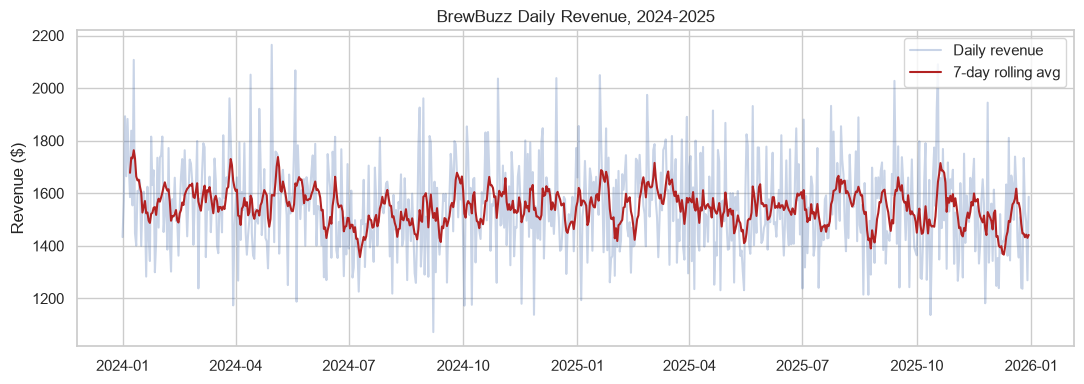

In [17]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(daily_revenue.index, daily_revenue.values, alpha=0.3, label="Daily revenue")
ax.plot(rolling_7d.index, rolling_7d.values, color="firebrick", label="7-day rolling avg")
ax.set_title("BrewBuzz Daily Revenue, 2024-2025")
ax.set_ylabel("Revenue ($)")
ax.legend()
plt.tight_layout()
plt.show()

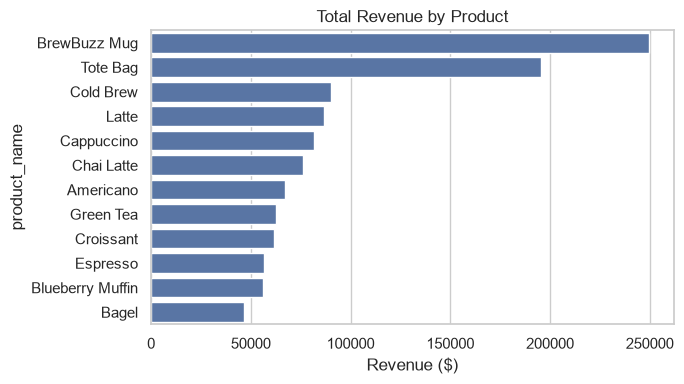

In [18]:
top_products = merged.groupby("product_name")["order_total_calc"].sum().sort_values(ascending=False)
plt.figure(figsize=(7, 4))
sns.barplot(x=top_products.values, y=top_products.index, orient="h")
plt.title("Total Revenue by Product")
plt.xlabel("Revenue ($)")
plt.tight_layout()
plt.show()

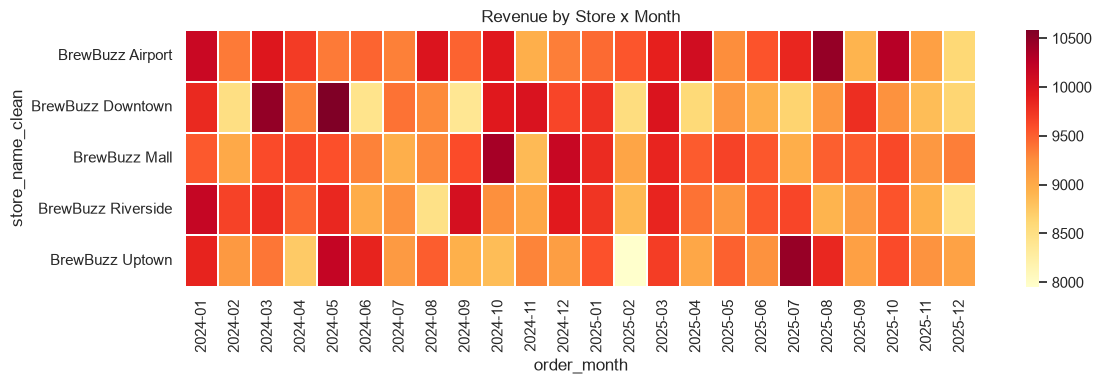

In [19]:
heat_data = merged.pivot_table(values="order_total_calc", index="store_name_clean", columns="order_month", aggfunc="sum")
plt.figure(figsize=(12, 4))
sns.heatmap(heat_data, cmap="YlOrRd", linewidths=0.3)
plt.title("Revenue by Store x Month")
plt.tight_layout()
plt.show()

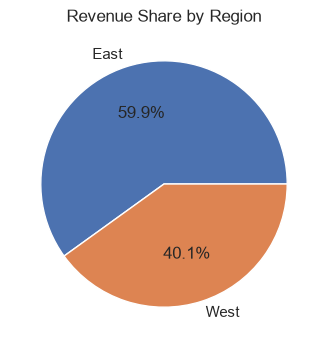

In [20]:
plt.figure(figsize=(6, 4))
region_revenue = merged.groupby("region")["order_total_calc"].sum()
plt.pie(region_revenue.values, labels=region_revenue.index, autopct="%1.1f%%")
plt.title("Revenue Share by Region")
plt.show()

## 13. Exporting the Results

In [17]:
merged.to_csv("../data/brewbuzz_clean.csv", index=False)
customers.to_csv("../data/brewbuzz_customer_tiers.csv", index=False)
audit_trail.to_json("../data/brewbuzz_audit_trail.json", orient="records", indent=2)
print(f"wrote {len(merged):,} clean rows, {len(customers):,} customer records, and the audit trail")

wrote 98,230 clean rows, 19,849 customer records, and the audit trail


## 14. Executive Summary

In [20]:
print(f"Rows loaded:              {rows_in:,}")
print(f"Rows after cleaning:       {len(merged):,} ({len(merged)/rows_in*100:.1f}% kept)")
print(f"Trustworthy total revenue: ${merged['order_total_calc'].sum():,.2f}")
print(f"Top region:                {merged.groupby('region')['order_total_calc'].sum().idxmax()}")
print(f"Top store:                 {merged.groupby('store_name_clean')['order_total_calc'].sum().idxmax()}")
# print(f"Top product:               {top_products.idxmax()}")
print(f"Unusable customer emails:  {(~merged['email_valid']).sum():,} of {len(merged):,} rows")
print(f"Platinum-tier customers:   {(customers['tier'] == 'Platinum').sum():,}")

Rows loaded:              100,000
Rows after cleaning:       98,230 (98.2% kept)
Trustworthy total revenue: $1,130,725.26
Top region:                East
Top store:                 BrewBuzz Airport
Unusable customer emails:  8,180 of 98,230 rows
Platinum-tier customers:   4,962
